In [1]:
library(tidyverse)
library(mgcv)
library(patchwork)

dat <- readRDS("../../DATA/processed/CARIACO_EnvData_combined.rds")
fish <- readRDS("../../DATA/processed/fisheries.rds")

# Parse dates
dat <- dat %>%
  mutate(
    month = as.integer(sub("-.*", "", time_month)),
    year  = as.integer(sub(".*-", "", time_month)),
    date  = as.Date(paste(year, month, "15", sep = "-"))
  )

# 3-season classification
get_season_3cat <- function(months) {
  season_lookup <- c(
    "12" = "Upwelling", "01" = "Upwelling", "02" = "Upwelling",
    "03" = "Upwelling", "04" = "Upwelling", "05" = "Upwelling",
    "06" = "Secondary Upwelling", "07" = "Secondary Upwelling", "08" = "Secondary Upwelling",
    "09" = "Rainy", "10" = "Rainy", "11" = "Rainy"
  )
  factor(season_lookup[sprintf("%02d", months)], 
         levels = c("Upwelling", "Secondary Upwelling", "Rainy"))
}

dat <- dat %>%
  mutate(season = get_season_3cat(month))

# Merge sardine landings onto monthly data by year
dat <- dat %>%
  left_join(fish, by = "year")

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Lade nötiges Paket: nlme


Attache Paket: ‘nlme’


Das folgende Objekt ist maskiert ‘package:dplyr’:

    collapse


This is mgcv 1.9-4. For overview type '?mgcv'.



In [2]:
library(tidyverse)
library(mgcv)
library(patchwork)

dat <- readRDS("../../DATA/processed/CARIACO_EnvData_combined.rds")
fish <- readRDS("../../DATA/processed/fisheries.rds")

# Parse dates
dat <- dat %>%
  mutate(
    month = as.integer(sub("-.*", "", time_month)),
    year  = as.integer(sub(".*-", "", time_month)),
    date  = as.Date(paste(year, month, "15", sep = "-"))
  )

# 3-season classification
get_season_3cat <- function(months) {
  season_lookup <- c(
    "12" = "Upwelling", "01" = "Upwelling", "02" = "Upwelling",
    "03" = "Upwelling", "04" = "Upwelling", "05" = "Upwelling",
    "06" = "Secondary Upwelling", "07" = "Secondary Upwelling", "08" = "Secondary Upwelling",
    "09" = "Rainy", "10" = "Rainy", "11" = "Rainy"
  )
  factor(season_lookup[sprintf("%02d", months)], 
         levels = c("Upwelling", "Secondary Upwelling", "Rainy"))
}

dat <- dat %>%
  mutate(season = get_season_3cat(month))

# Merge sardine landings onto monthly data by year
dat <- dat %>%
  left_join(fish, by = "year")

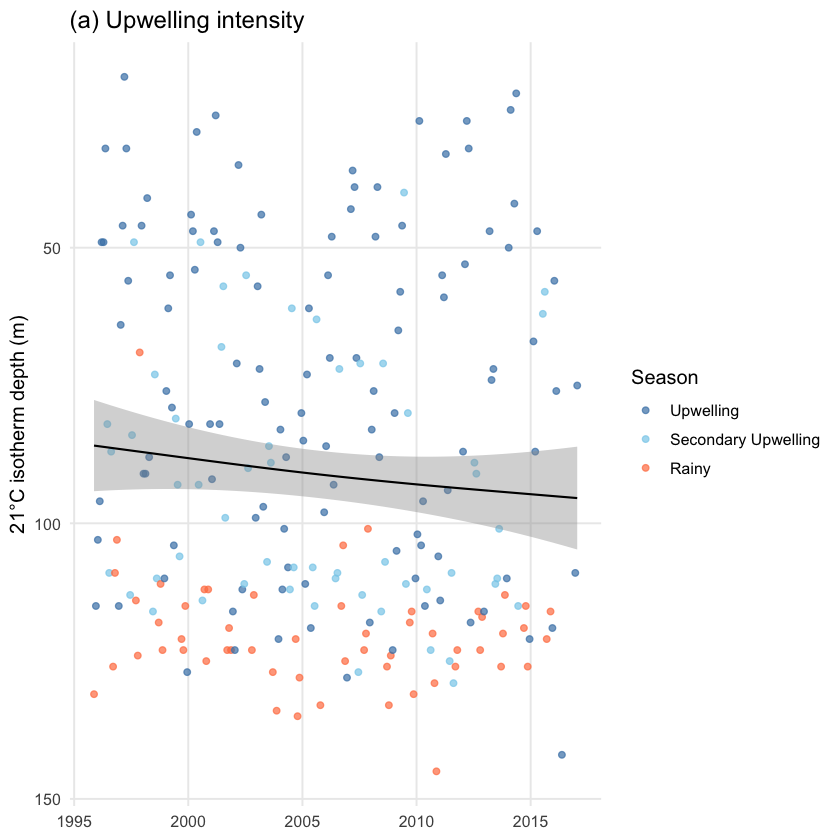

In [7]:
pa <- dat %>%
  filter(!is.na(Isotherm_21)) %>%
  ggplot(aes(date, Isotherm_21)) +
  geom_point(aes(color = season), size = 1.5, alpha = 0.7) +
  geom_smooth(method = "gam", formula = y ~ s(x), color = "black", linewidth = 0.6, se = TRUE) +
  scale_y_reverse() +
  scale_color_manual(values = c("Upwelling" = "steelblue", 
                                "Secondary Upwelling" = "skyblue", 
                                "Rainy" = "coral")) +
  labs(y = "21°C isotherm depth (m)", title = "(a) Upwelling intensity", color = "Season") +
  theme_minimal(base_size = 12) +
  theme(panel.grid.minor = element_blank(), axis.title.x = element_blank())

print(pa)

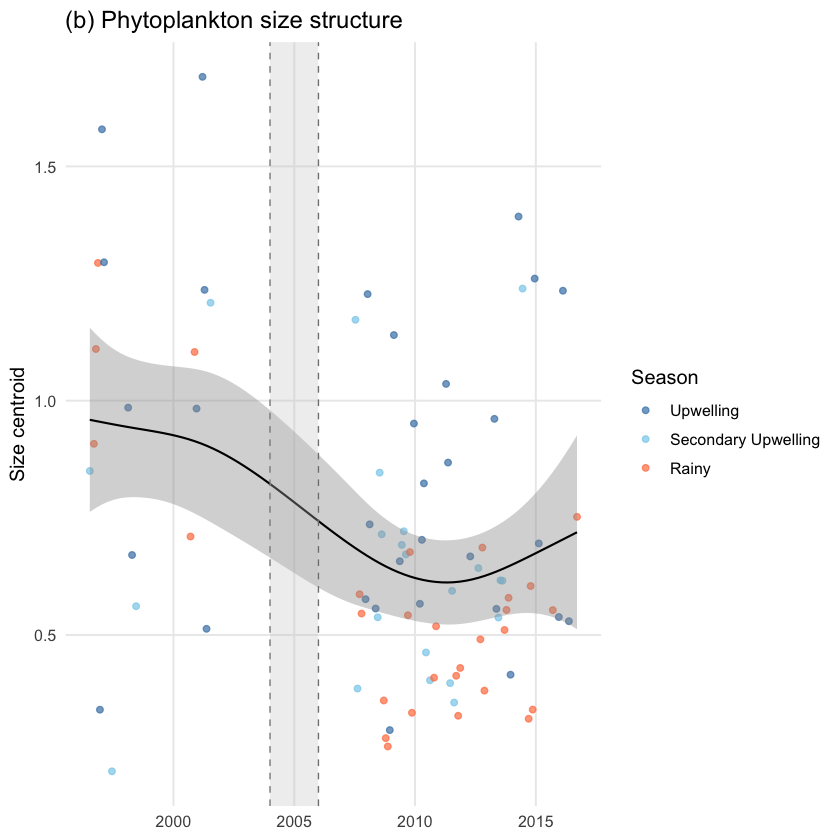

In [3]:
pb <- dat %>%
  filter(!is.na(size_centroid)) %>%
  ggplot(aes(date, size_centroid)) +
  geom_point(aes(color = season), size = 1.5, alpha = 0.7) +
  geom_smooth(method = "gam", formula = y ~ s(x), color = "black", linewidth = 0.6, se = TRUE) +
  geom_vline(xintercept = as.Date(c("2004-01-01", "2006-01-01")),
             linetype = "dashed", color = "grey50", linewidth = 0.4) +
  annotate("rect", xmin = as.Date("2004-01-01"), xmax = as.Date("2006-01-01"),
           ymin = -Inf, ymax = Inf, fill = "grey80", alpha = 0.3) +
  scale_color_manual(values = c("Upwelling" = "steelblue", 
                                "Secondary Upwelling" = "skyblue", 
                                "Rainy" = "coral")) +
  labs(y = "Size centroid", title = "(b) Phytoplankton size structure", color = "Season") +
  theme_minimal(base_size = 12) +
  theme(panel.grid.minor = element_blank(), axis.title.x = element_blank())

print(pb)

`geom_smooth()` using formula = 'y ~ x'


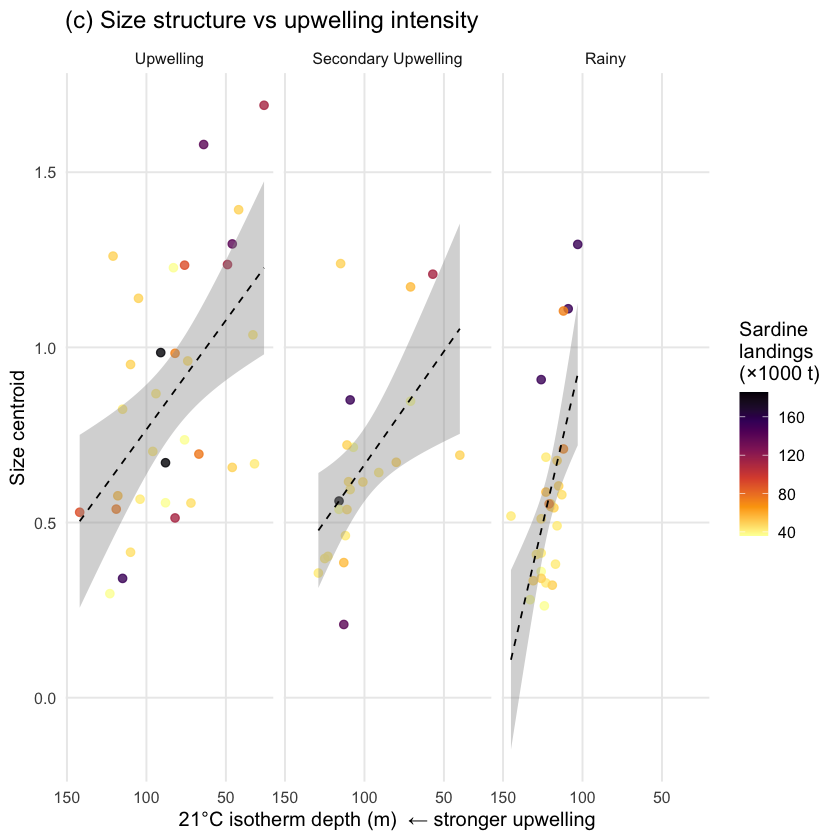

In [4]:
pc <- dat %>%
  filter(!is.na(size_centroid), !is.na(Isotherm_21), !is.na(sardinelandings)) %>%
  ggplot(aes(Isotherm_21, size_centroid)) +
  geom_point(aes(color = sardinelandings / 1000), size = 2, alpha = 0.8) +
  geom_smooth(method = "lm", color = "black", linewidth = 0.5, se = TRUE, linetype = "dashed") +
  scale_color_viridis_c(option = "inferno", direction = -1, name = "Sardine\nlandings\n(×1000 t)") +
  scale_x_reverse() +  # shallow (strong upwelling) on right
  facet_wrap(~season, nrow = 1) +
  labs(x = "21°C isotherm depth (m)  ← stronger upwelling", 
       y = "Size centroid",
       title = "(c) Size structure vs upwelling intensity") +
  theme_minimal(base_size = 12) +
  theme(panel.grid.minor = element_blank())

print(pc)

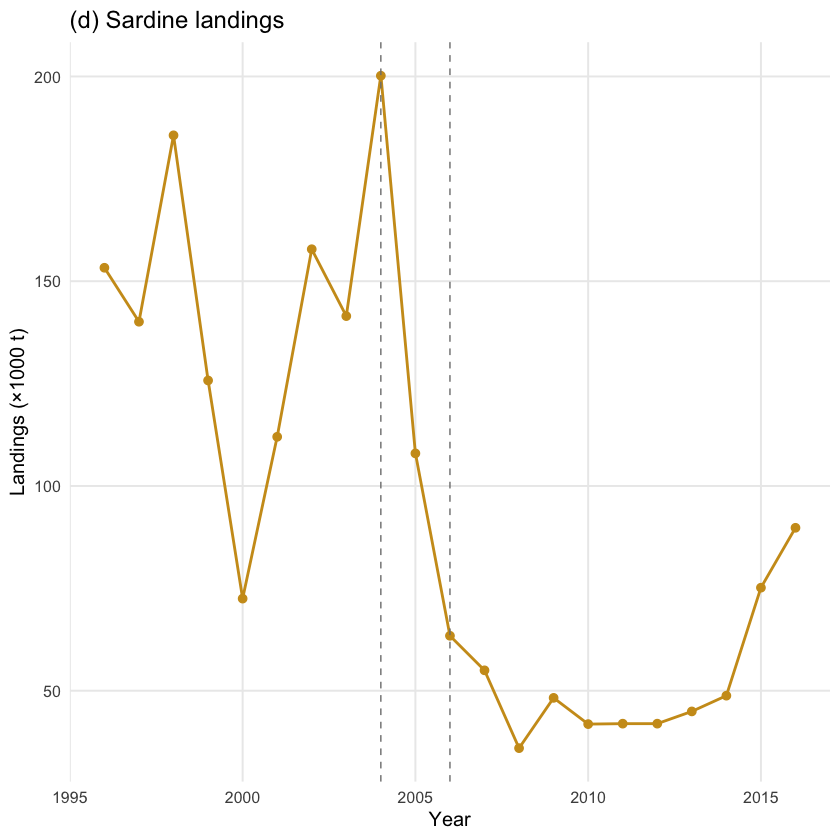

In [5]:
pd <- fish %>%
  filter(year >= 1996, year <= 2016) %>%
  ggplot(aes(year, sardinelandings / 1000)) +
  geom_line(color = "goldenrod3", linewidth = 0.8) +
  geom_point(color = "goldenrod3", size = 2) +
  geom_vline(xintercept = c(2004, 2006), linetype = "dashed", color = "grey50", linewidth = 0.4) +
  labs(y = "Landings (×1000 t)", title = "(d) Sardine landings", x = "Year") +
  theme_minimal(base_size = 12) +
  theme(panel.grid.minor = element_blank())

print(pd)

`geom_smooth()` using formula = 'y ~ x'


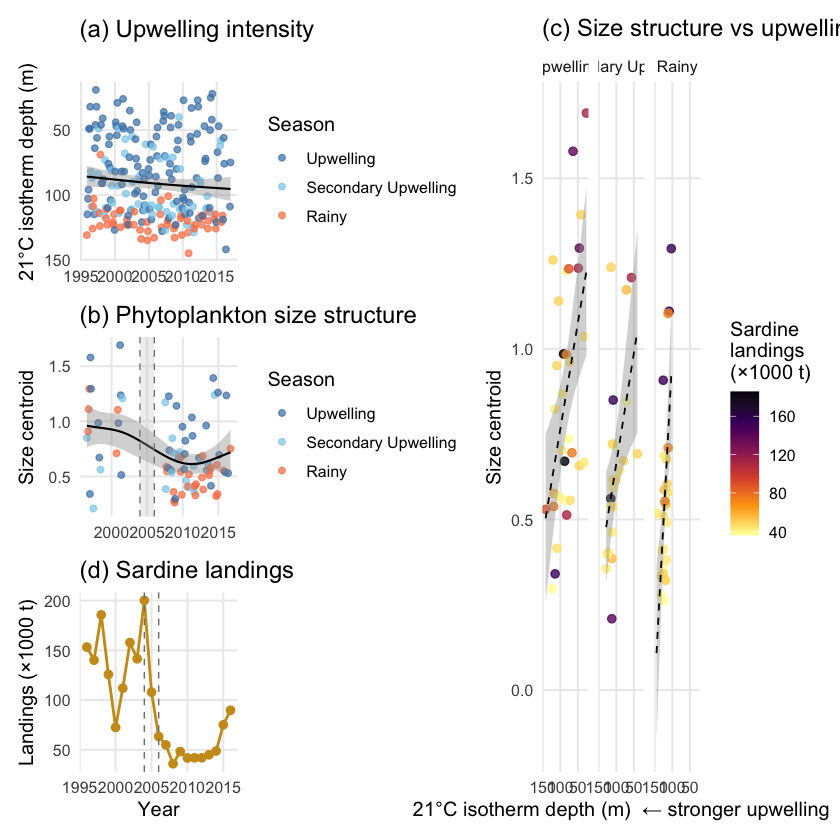

In [8]:
# Panels a, b, d are time-based; c is a relationship plot
# You may want to present (a, b, d) stacked and (c) separately,
# or arrange all four:

(pa / pb / pd) | pc

In [10]:
dat %>%
  filter(!is.na(size_centroid), !is.na(BIOMASS_200), !is.na(Isotherm_21)) %>%
  summarise(
    n = n(),
    year_min = min(year),
    year_max = max(year),
    n_upwelling = sum(season == "Upwelling"),
    n_secondary = sum(season == "Secondary Upwelling"),
    n_rainy = sum(season == "Rainy")
  ) %>% print()

   n year_min year_max n_upwelling n_secondary n_rainy
1 59     2007     2016          22          17      20


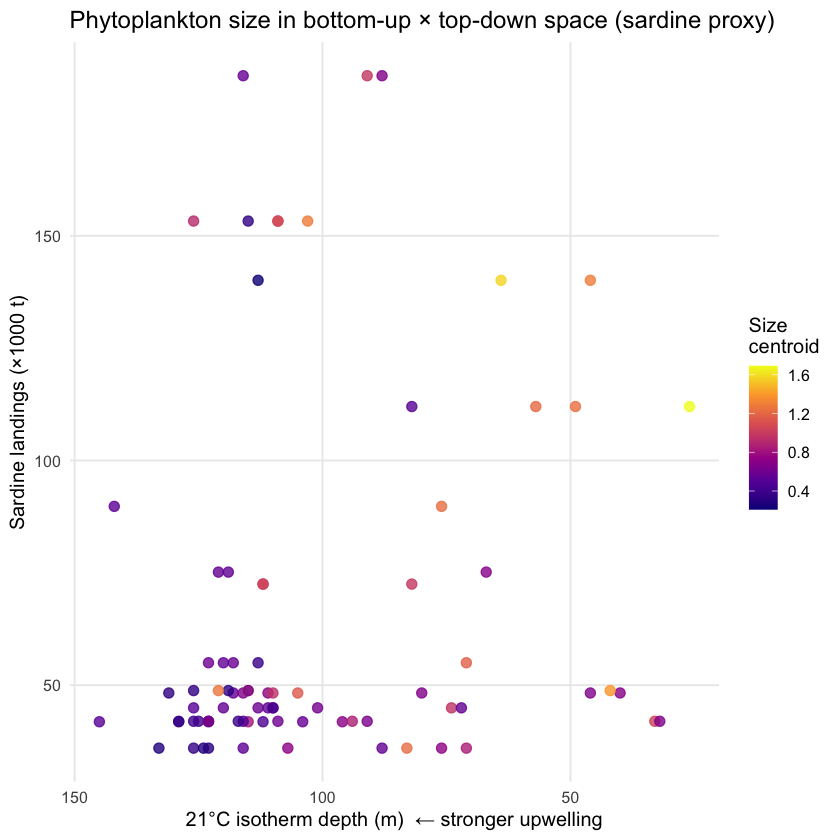

In [14]:
# Sardine landings are annual, so every monthly obs in a given year
# gets the same sardine value. This uses all HPLC data (1996-2016).

p_phase_fish <- dat %>%
  filter(!is.na(size_centroid), !is.na(Isotherm_21), !is.na(sardinelandings)) %>%
  ggplot(aes(x = Isotherm_21, y = sardinelandings / 1000, color = size_centroid)) +
  geom_point(size = 2.5, alpha = 0.8) +
  scale_x_reverse(name = "21°C isotherm depth (m)  ← stronger upwelling") +
  scale_color_viridis_c(option = "plasma", name = "Size\ncentroid") +
  #facet_wrap(~season, nrow = 1) +
  labs(y = "Sardine landings (×1000 t)",
       title = "Phytoplankton size in bottom-up × top-down space (sardine proxy)") +
  theme_minimal(base_size = 12) +
  theme(panel.grid.minor = element_blank())

print(p_phase_fish)

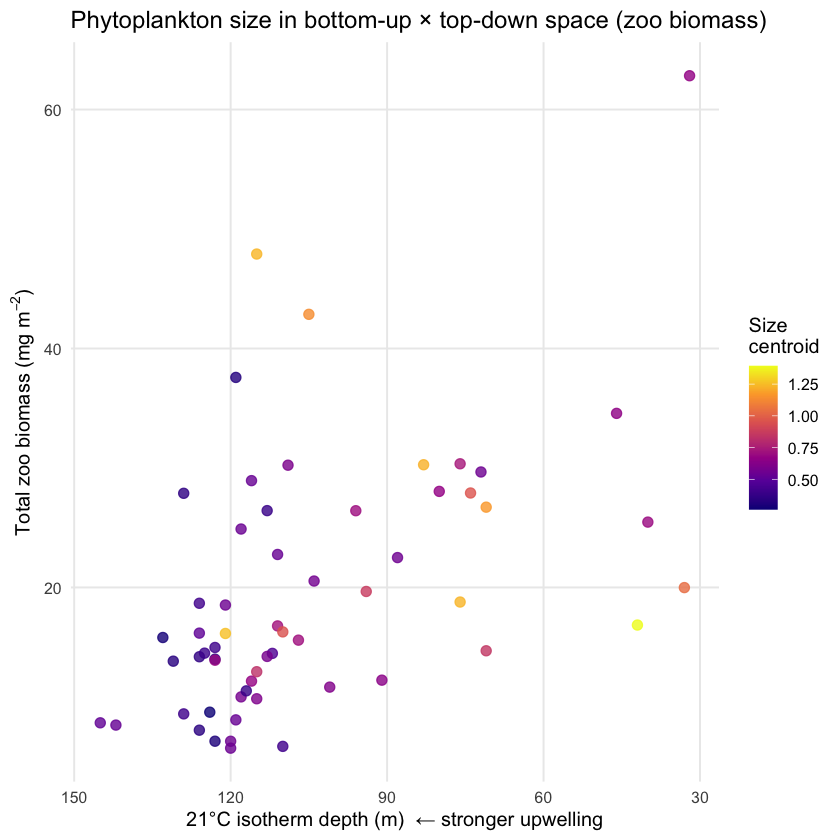

In [13]:
p_phase_zoo_total <- dat %>%
  filter(!is.na(size_centroid), !is.na(BIOMASS_200), !is.na(Isotherm_21)) %>%
  mutate(zoo_total = BIOMASS_200 + BIOMASS_500) %>%
  ggplot(aes(x = Isotherm_21, y = zoo_total, color = size_centroid)) +
  geom_point(size = 2.5, alpha = 0.8) +
  scale_x_reverse(name = "21°C isotherm depth (m)  ← stronger upwelling") +
  scale_color_viridis_c(option = "plasma", name = "Size\ncentroid") +
  #facet_wrap(~season, nrow = 1) +
  labs(y = expression("Total zoo biomass (mg m"^{-2}*")"),
       title = "Phytoplankton size in bottom-up × top-down space (zoo biomass)") +
  theme_minimal(base_size = 12) +
  theme(panel.grid.minor = element_blank())

print(p_phase_zoo_total)

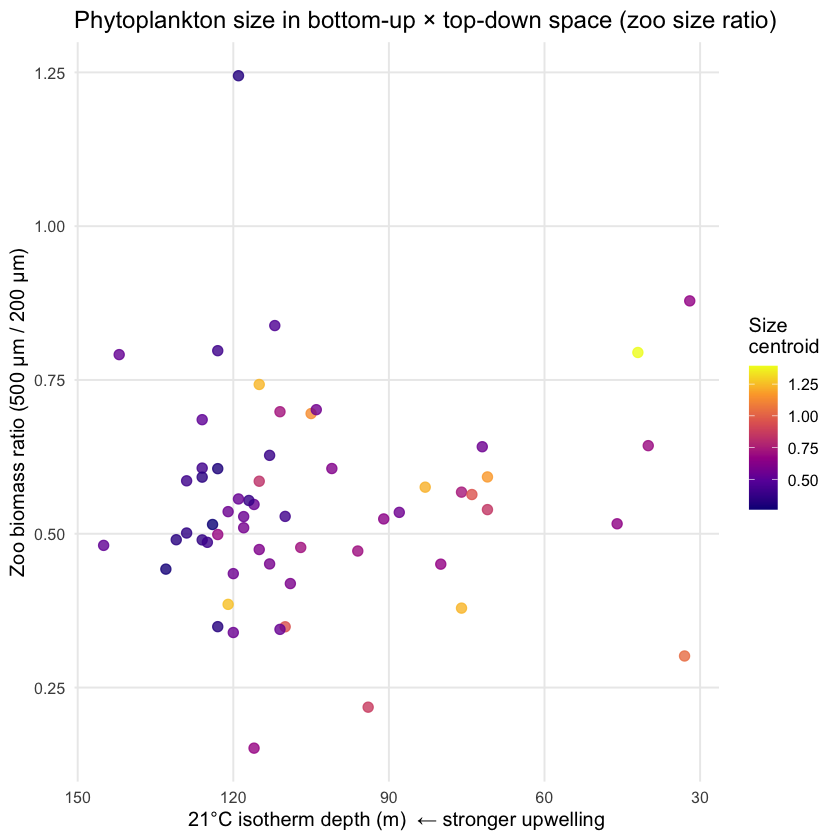

In [16]:
p_phase_zoo_ratio <- dat %>%
  filter(!is.na(size_centroid), !is.na(BIOMASS_200), !is.na(BIOMASS_500), 
         !is.na(Isotherm_21), BIOMASS_200 > 0) %>%
  mutate(zoo_ratio = BIOMASS_500 / BIOMASS_200) %>%
  ggplot(aes(x = Isotherm_21, y = zoo_ratio, color = size_centroid)) +
  geom_point(size = 2.5, alpha = 0.8) +
  scale_x_reverse(name = "21°C isotherm depth (m)  ← stronger upwelling") +
  scale_color_viridis_c(option = "plasma", name = "Size\ncentroid") +
  #facet_wrap(~season, nrow = 1) +
  labs(y = "Zoo biomass ratio (500 µm / 200 µm)",
       title = "Phytoplankton size in bottom-up × top-down space (zoo size ratio)") +
  theme_minimal(base_size = 12) +
  theme(panel.grid.minor = element_blank())

print(p_phase_zoo_ratio)


=== Kruskal-Wallis test ===

	Kruskal-Wallis rank sum test

data:  size_centroid by ui
Kruskal-Wallis chi-squared = 15.944, df = 3, p-value = 0.001164


=== Pairwise Wilcoxon (BH-adjusted) ===

	Pairwise comparisons using Wilcoxon rank sum test with continuity correction 

data:  kw_dat$size_centroid and kw_dat$ui 

        moderate relaxed strong
relaxed 0.027    -       -     
strong  0.300    0.187   -     
weak    0.375    0.027   0.250 

P value adjustment method: BH 

=== Group summaries ===
# A tibble: 4 × 5
  ui           n median  mean     sd
  <fct>    <int>  <dbl> <dbl>  <dbl>
1 strong       1  1.69  1.69  NA    
2 moderate     7  1.04  0.997  0.322
3 weak        11  0.961 0.887  0.283
4 relaxed     62  0.564 0.631  0.290


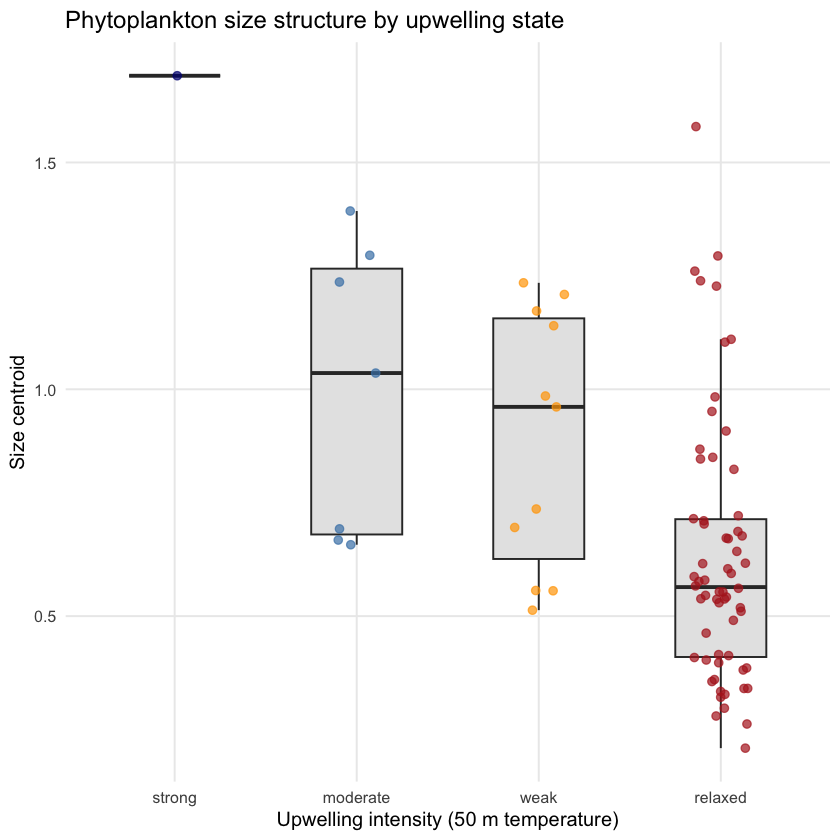

In [17]:
# =============================================
# PLOT 1: Size centroid by upwelling category
# =============================================

p1 <- dat %>%
  filter(!is.na(size_centroid), !is.na(ui)) %>%
  mutate(ui = factor(ui, levels = c("strong", "moderate", "weak", "relaxed"))) %>%
  ggplot(aes(x = ui, y = size_centroid)) +
  geom_boxplot(outlier.shape = NA, fill = "grey90", width = 0.5) +
  geom_jitter(aes(color = ui), width = 0.15, size = 2, alpha = 0.7) +
  scale_color_manual(values = c("strong" = "navy", "moderate" = "steelblue",
                                "weak" = "orange", "relaxed" = "firebrick"),
                     guide = "none") +
  labs(x = "Upwelling intensity (50 m temperature)",
       y = "Size centroid",
       title = "Phytoplankton size structure by upwelling state") +
  theme_minimal(base_size = 12) +
  theme(panel.grid.minor = element_blank())

print(p1)

# Quick stats: Kruskal-Wallis + pairwise Wilcox
cat("\n=== Kruskal-Wallis test ===\n")
kw_dat <- dat %>% filter(!is.na(size_centroid), !is.na(ui))
print(kruskal.test(size_centroid ~ ui, data = kw_dat))

cat("\n=== Pairwise Wilcoxon (BH-adjusted) ===\n")
print(pairwise.wilcox.test(kw_dat$size_centroid, kw_dat$ui, p.adjust.method = "BH"))

cat("\n=== Group summaries ===\n")
kw_dat %>%
  mutate(ui = factor(ui, levels = c("strong", "moderate", "weak", "relaxed"))) %>%
  group_by(ui) %>%
  summarise(n = n(), median = median(size_centroid), 
            mean = mean(size_centroid), sd = sd(size_centroid)) %>%
  print()


=== Wilcoxon test: upwelling vs relaxed ===

	Wilcoxon rank sum test with continuity correction

data:  size_centroid by upwelling
W = 246, p-value = 0.0001348
alternative hypothesis: true location shift is not equal to 0

# A tibble: 2 × 5
  upwelling     n median  mean    sd
  <chr>     <int>  <dbl> <dbl> <dbl>
1 relaxed      62  0.564 0.631 0.290
2 upwelling    19  0.985 0.970 0.335


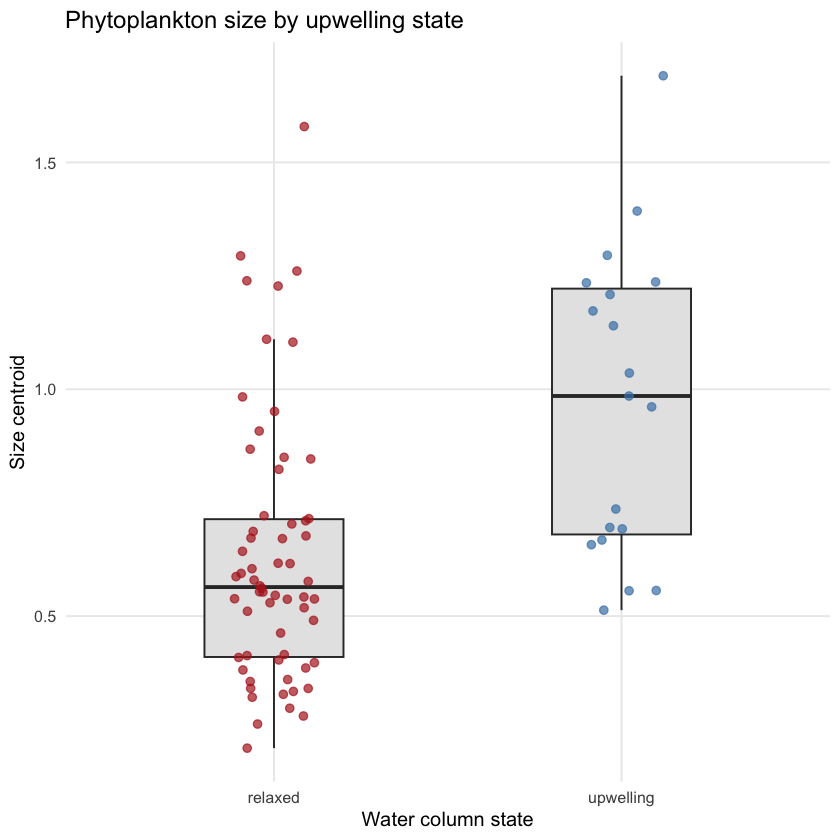

In [19]:
# =============================================
# PLOT 1 (revised): Upwelling vs Relaxed
# =============================================

p1 <- dat %>%
  filter(!is.na(size_centroid), !is.na(upwelling)) %>%
  ggplot(aes(x = upwelling, y = size_centroid)) +
  geom_boxplot(outlier.shape = NA, fill = "grey90", width = 0.4) +
  geom_jitter(aes(color = upwelling), width = 0.12, size = 2, alpha = 0.7) +
  scale_color_manual(values = c("upwelling" = "steelblue", "relaxed" = "firebrick"),
                     guide = "none") +
  labs(x = "Water column state", y = "Size centroid",
       title = "Phytoplankton size by upwelling state") +
  theme_minimal(base_size = 12) +
  theme(panel.grid.minor = element_blank())

print(p1)

cat("\n=== Wilcoxon test: upwelling vs relaxed ===\n")
w_dat <- dat %>% filter(!is.na(size_centroid), !is.na(upwelling))
print(wilcox.test(size_centroid ~ upwelling, data = w_dat))

w_dat %>%
  group_by(upwelling) %>%
  summarise(n = n(), median = median(size_centroid),
            mean = mean(size_centroid), sd = sd(size_centroid)) %>%
  print()

=== Transition categories ===
                transition  n
1                upwelling 19
2 relaxed (post-upwelling) 11
3                  relaxed 51

=== Summary by transition category ===
# A tibble: 3 × 5
  transition                   n median  mean    sd
  <fct>                    <int>  <dbl> <dbl> <dbl>
1 upwelling                   19  0.985 0.970 0.335
2 relaxed (post-upwelling)    11  0.553 0.627 0.266
3 relaxed                     51  0.567 0.631 0.297


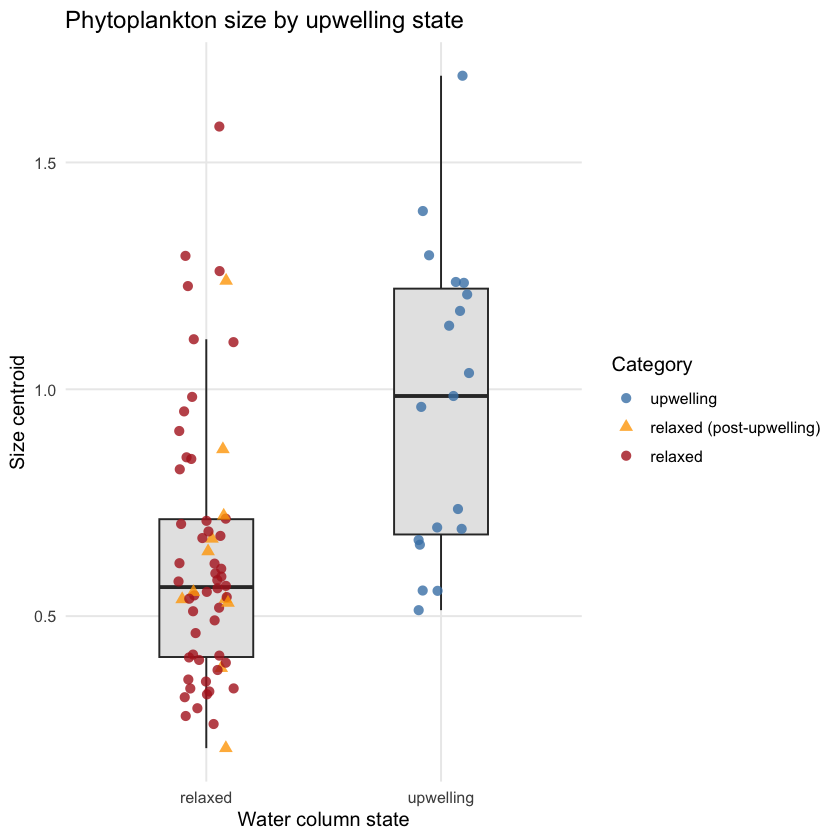

In [22]:
# =============================================
# PLOT 1 (revised): color transition months
# =============================================

# Flag months where the previous month was upwelling
p1_dat <- dat %>%
  filter(!is.na(size_centroid), !is.na(upwelling)) %>%
  arrange(date) %>%
  mutate(
    prev_upwelling = lag(upwelling),
    # Also check: is this a relaxed month immediately following an upwelling month?
    transition = case_when(
      upwelling == "upwelling" ~ "upwelling",
      upwelling == "relaxed" & prev_upwelling == "upwelling" ~ "relaxed (post-upwelling)",
      TRUE ~ "relaxed"
    ),
    transition = factor(transition, levels = c("upwelling", "relaxed (post-upwelling)", "relaxed"))
  )

# Check counts
cat("=== Transition categories ===\n")
p1_dat %>% count(transition) %>% print()

p1_rev <- p1_dat %>%
  ggplot(aes(x = upwelling, y = size_centroid)) +
  geom_boxplot(outlier.shape = NA, fill = "grey90", width = 0.4) +
  geom_jitter(aes(color = transition, shape = transition), width = 0.12, size = 2.5, alpha = 0.8) +
  scale_color_manual(values = c("upwelling" = "steelblue",
                                "relaxed (post-upwelling)" = "orange",
                                "relaxed" = "firebrick")) +
  scale_shape_manual(values = c("upwelling" = 16, "relaxed (post-upwelling)" = 17, "relaxed" = 16)) +
  labs(x = "Water column state", y = "Size centroid",
       title = "Phytoplankton size by upwelling state",
       color = "Category", shape = "Category") +
  theme_minimal(base_size = 12) +
  theme(panel.grid.minor = element_blank())

print(p1_rev)

# Summary by transition category
cat("\n=== Summary by transition category ===\n")
p1_dat %>%
  group_by(transition) %>%
  summarise(n = n(), median = median(size_centroid),
            mean = mean(size_centroid), sd = sd(size_centroid)) %>%
  print()

In [24]:
dat %>%
  filter(!is.na(size_centroid), !is.na(upwelling),
         upwelling == "relaxed", size_centroid > 1.0) %>%
  select(time_month, year, month, size_centroid, Isotherm_21, 
         Tot_Chl_a, BIOMASS_200, sardinelandings) %>%
  arrange(desc(size_centroid)) %>%
  print()

  time_month year month size_centroid Isotherm_21 Tot_Chl_a BIOMASS_200
1    01-1997 1997     1      1.579114          64 107.85121          NA
2    11-1996 1996    11      1.293976         103  39.68593          NA
3    12-2014 2014    12      1.260555         121  77.51811     11.6572
4    06-2014 2014     6      1.239198         115  58.76180     27.4901
5    01-2008 2008     1      1.227441          83  23.72649     19.2100
6    10-1996 1996    10      1.110257         109  29.85753          NA
7    11-2000 2000    11      1.103900         112        NA          NA
  sardinelandings
1       140103.83
2       153286.13
3        48790.04
4        48790.04
5        35978.65
6       153286.13
7        72493.24


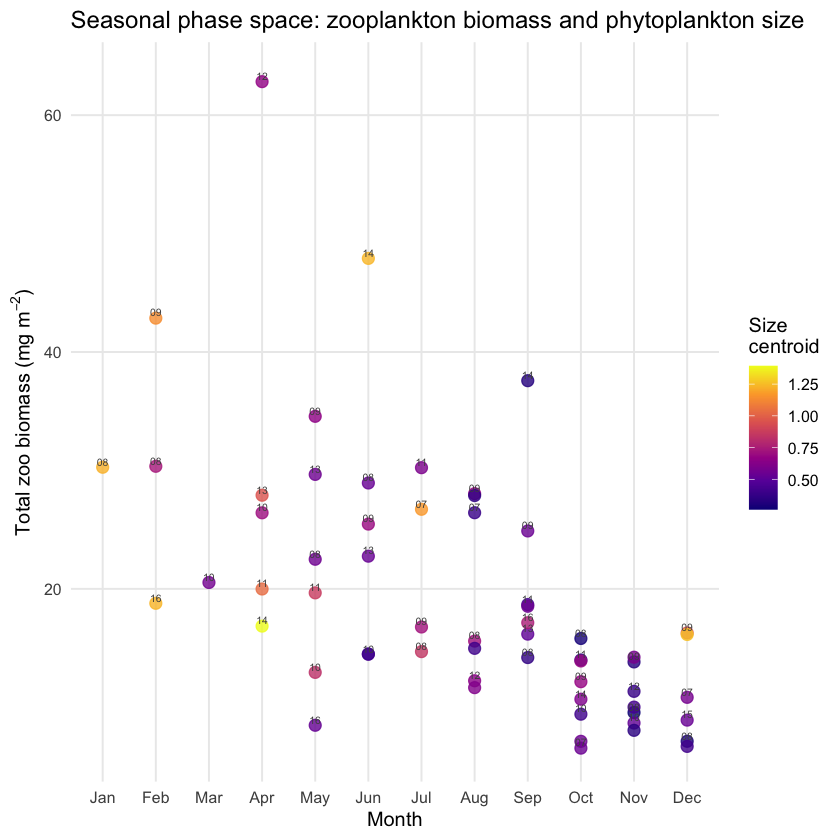

In [18]:
# =============================================
# PLOT 2: Monthly phase space (zoo × month × size)
# =============================================

p2 <- dat %>%
  filter(!is.na(size_centroid), !is.na(BIOMASS_200)) %>%
  mutate(zoo_total = BIOMASS_200 + BIOMASS_500,
         month_label = factor(month.abb[month], levels = month.abb)) %>%
  ggplot(aes(x = month_label, y = zoo_total, color = size_centroid)) +
  geom_point(size = 3, alpha = 0.8) +
  geom_text(aes(label = substr(year, 3, 4)), size = 2.2, nudge_y = 0.5, 
            color = "grey30", check_overlap = TRUE) +
  scale_color_viridis_c(option = "plasma", name = "Size\ncentroid") +
  labs(x = "Month",
       y = expression("Total zoo biomass (mg m"^{-2}*")"),
       title = "Seasonal phase space: zooplankton biomass and phytoplankton size") +
  theme_minimal(base_size = 12) +
  theme(panel.grid.minor = element_blank())

print(p2)

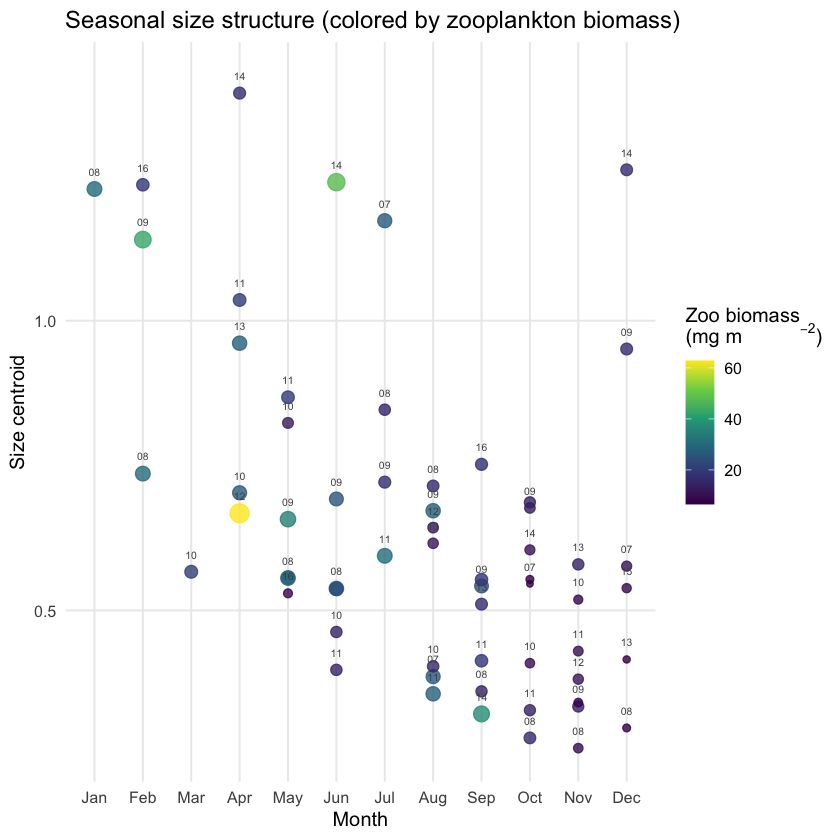

In [20]:
# =============================================
# PLOT 2a: Monthly size centroid, colored by zoo biomass
# =============================================

p2a <- dat %>%
  filter(!is.na(size_centroid), !is.na(BIOMASS_200)) %>%
  mutate(zoo_total = BIOMASS_200 + BIOMASS_500,
         month_label = factor(month.abb[month], levels = month.abb)) %>%
  ggplot(aes(x = month_label, y = size_centroid)) +
  geom_point(aes(color = zoo_total, size = zoo_total), alpha = 0.8) +
  geom_text(aes(label = substr(year, 3, 4)), size = 2.2, nudge_y = 0.03,
            color = "grey30", check_overlap = TRUE) +
  scale_color_viridis_c(option = "viridis", name = expression("Zoo biomass\n(mg m"^{-2}*")")) +
  scale_size_continuous(range = c(1.5, 5), guide = "none") +
  labs(x = "Month", y = "Size centroid",
       title = "Seasonal size structure (colored by zooplankton biomass)") +
  theme_minimal(base_size = 12) +
  theme(panel.grid.minor = element_blank())

print(p2a)

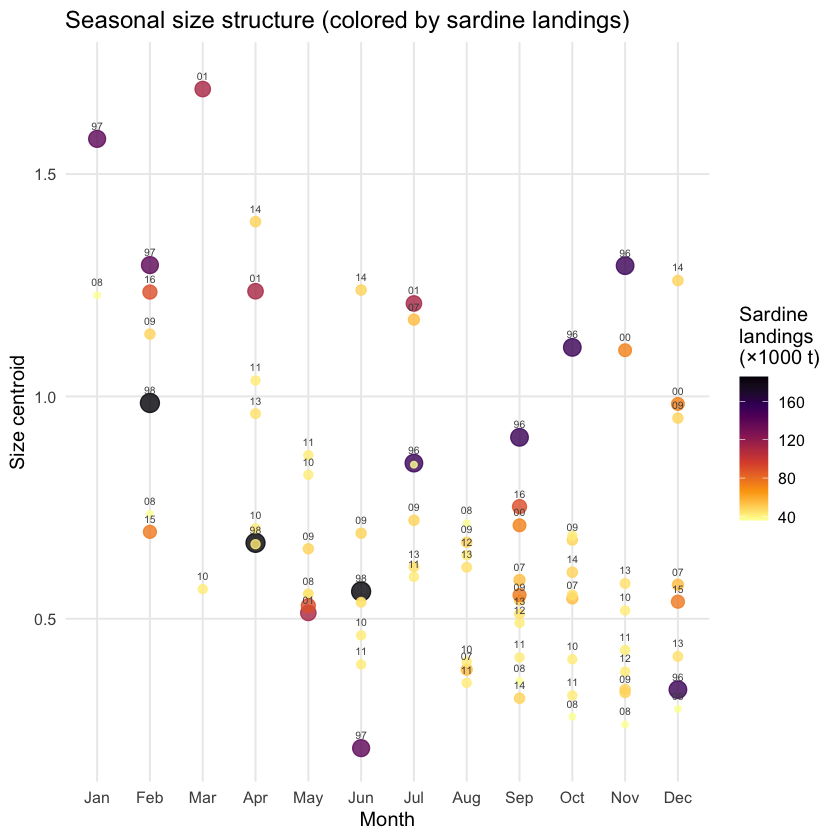

In [21]:
# =============================================
# PLOT 2b: Monthly size centroid, colored by sardine landings
# =============================================

p2b <- dat %>%
  filter(!is.na(size_centroid), !is.na(sardinelandings)) %>%
  mutate(month_label = factor(month.abb[month], levels = month.abb)) %>%
  ggplot(aes(x = month_label, y = size_centroid)) +
  geom_point(aes(color = sardinelandings / 1000, size = sardinelandings / 1000), alpha = 0.8) +
  geom_text(aes(label = substr(year, 3, 4)), size = 2.2, nudge_y = 0.03,
            color = "grey30", check_overlap = TRUE) +
  scale_color_viridis_c(option = "inferno", direction = -1, name = "Sardine\nlandings\n(×1000 t)") +
  scale_size_continuous(range = c(1.5, 5), guide = "none") +
  labs(x = "Month", y = "Size centroid",
       title = "Seasonal size structure (colored by sardine landings)") +
  theme_minimal(base_size = 12) +
  theme(panel.grid.minor = element_blank())

print(p2b)

=== Linear model: size_centroid ~ Isotherm_21 ===



Call:
lm(formula = size_centroid ~ Isotherm_21, data = sc_dat)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.54220 -0.16892 -0.04418  0.13473  0.69404 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept)  1.441138   0.111719  12.900  < 2e-16 ***
Isotherm_21 -0.007228   0.001066  -6.784 1.93e-09 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.2655 on 79 degrees of freedom
Multiple R-squared:  0.3681,	Adjusted R-squared:  0.3601 
F-statistic: 46.02 on 1 and 79 DF,  p-value: 1.932e-09


`geom_smooth()` using formula = 'y ~ x'


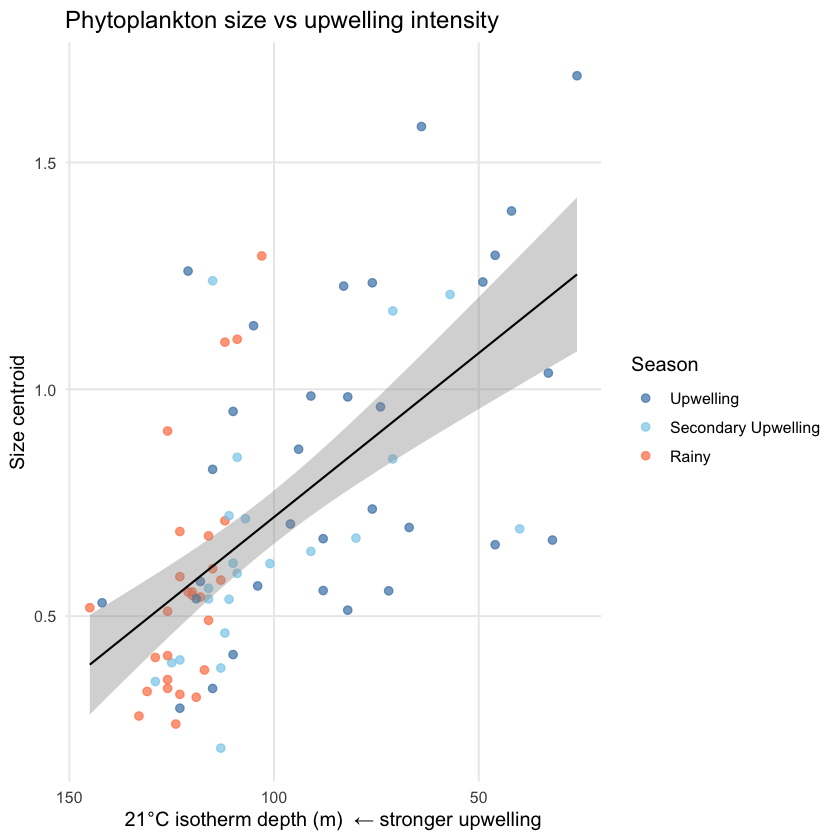

In [25]:
# =============================================
# Size centroid vs Isotherm depth
# =============================================

sc_dat <- dat %>%
  filter(!is.na(size_centroid), !is.na(Isotherm_21))

# Fit linear model
lm_fit <- lm(size_centroid ~ Isotherm_21, data = sc_dat)

cat("=== Linear model: size_centroid ~ Isotherm_21 ===\n")
summary(lm_fit)

# Plot
p_sc <- sc_dat %>%
  ggplot(aes(x = Isotherm_21, y = size_centroid)) +
  geom_point(aes(color = season), size = 2, alpha = 0.7) +
  geom_smooth(method = "lm", color = "black", linewidth = 0.6, se = TRUE) +
  scale_x_reverse(name = "21°C isotherm depth (m)  ← stronger upwelling") +
  scale_color_manual(values = c("Upwelling" = "steelblue",
                                "Secondary Upwelling" = "skyblue",
                                "Rainy" = "coral")) +
  labs(y = "Size centroid",
       title = "Phytoplankton size vs upwelling intensity",
       color = "Season") +
  theme_minimal(base_size = 12) +
  theme(panel.grid.minor = element_blank())

print(p_sc)


=== Residuals ~ total zoo biomass ===
n = 59

	Spearman's rank correlation rho

data:  resid_zoo$resid and resid_zoo$zoo_total
S = 35590, p-value = 0.7628
alternative hypothesis: true rho is not equal to 0
sample estimates:
        rho 
-0.04003507 


Linear model:



Call:
lm(formula = resid ~ zoo_total, data = resid_zoo)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.48754 -0.13761 -0.04042  0.10722  0.73557 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)
(Intercept) -0.0369895  0.0652423  -0.567    0.573
zoo_total   -0.0002812  0.0029193  -0.096    0.924

Residual standard error: 0.2415 on 57 degrees of freedom
Multiple R-squared:  0.0001627,	Adjusted R-squared:  -0.01738 
F-statistic: 0.009275 on 1 and 57 DF,  p-value: 0.9236



=== Residuals ~ zoo 500:200 ratio ===
n = 59

	Spearman's rank correlation rho

data:  resid_ratio$resid and resid_ratio$zoo_ratio
S = 39366, p-value = 0.2549
alternative hypothesis: true rho is not equal to 0
sample estimates:
       rho 
-0.1503799 


=== Residuals ~ sardine landings ===
n = 81


Warning message in cor.test.default(resid_fish$resid, resid_fish$sardinelandings, :
“Kann exakten p-Wert bei Bindungen nicht berechnen”



	Spearman's rank correlation rho

data:  resid_fish$resid and resid_fish$sardinelandings
S = 56566, p-value = 0.0009213
alternative hypothesis: true rho is not equal to 0
sample estimates:
      rho 
0.3612651 


Linear model:



Call:
lm(formula = resid ~ sardinelandings, data = resid_fish)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.55717 -0.14147 -0.01212  0.10908  0.72788 

Coefficients:
                  Estimate Std. Error t value Pr(>|t|)   
(Intercept)     -1.277e-01  5.345e-02  -2.389  0.01927 * 
sardinelandings  1.924e-06  6.847e-07   2.810  0.00625 **
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.2532 on 79 degrees of freedom
Multiple R-squared:  0.09085,	Adjusted R-squared:  0.07934 
F-statistic: 7.895 on 1 and 79 DF,  p-value: 0.006247


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


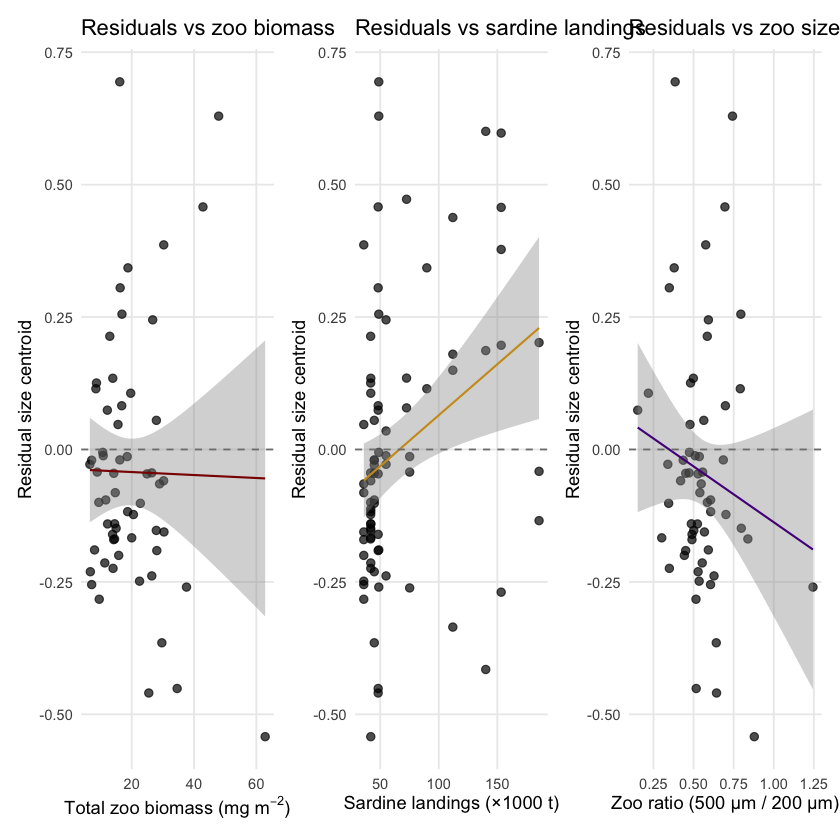

In [26]:
# =============================================
# Residual analysis
# =============================================

# Store residuals
sc_dat <- sc_dat %>%
  mutate(resid = residuals(lm_fit))

# --- Residuals vs zoo biomass (smaller n) ---
resid_zoo <- sc_dat %>%
  filter(!is.na(BIOMASS_200)) %>%
  mutate(zoo_total = BIOMASS_200 + BIOMASS_500)

cat("\n=== Residuals ~ total zoo biomass ===\n")
cat(sprintf("n = %d\n", nrow(resid_zoo)))
cor_zoo <- cor.test(resid_zoo$resid, resid_zoo$zoo_total, method = "spearman")
print(cor_zoo)

lm_resid_zoo <- lm(resid ~ zoo_total, data = resid_zoo)
cat("\nLinear model:\n")
summary(lm_resid_zoo)

# --- Residuals vs zoo 500:200 ratio ---
resid_ratio <- sc_dat %>%
  filter(!is.na(BIOMASS_200), !is.na(BIOMASS_500), BIOMASS_200 > 0) %>%
  mutate(zoo_ratio = BIOMASS_500 / BIOMASS_200)

cat("\n=== Residuals ~ zoo 500:200 ratio ===\n")
cat(sprintf("n = %d\n", nrow(resid_ratio)))
cor_ratio <- cor.test(resid_ratio$resid, resid_ratio$zoo_ratio, method = "spearman")
print(cor_ratio)

# --- Residuals vs sardine landings ---
resid_fish <- sc_dat %>%
  filter(!is.na(sardinelandings))

cat("\n=== Residuals ~ sardine landings ===\n")
cat(sprintf("n = %d\n", nrow(resid_fish)))
cor_fish <- cor.test(resid_fish$resid, resid_fish$sardinelandings, method = "spearman")
print(cor_fish)

lm_resid_fish <- lm(resid ~ sardinelandings, data = resid_fish)
cat("\nLinear model:\n")
summary(lm_resid_fish)

# --- Diagnostic plots ---
library(patchwork)

p_rz <- resid_zoo %>%
  ggplot(aes(zoo_total, resid)) +
  geom_point(size = 2, alpha = 0.7) +
  geom_smooth(method = "lm", color = "darkred", se = TRUE, linewidth = 0.6) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "grey50") +
  labs(x = expression("Total zoo biomass (mg m"^{-2}*")"),
       y = "Residual size centroid",
       title = "Residuals vs zoo biomass") +
  theme_minimal(base_size = 11) +
  theme(panel.grid.minor = element_blank())

p_rf <- resid_fish %>%
  ggplot(aes(sardinelandings / 1000, resid)) +
  geom_point(size = 2, alpha = 0.7) +
  geom_smooth(method = "lm", color = "goldenrod3", se = TRUE, linewidth = 0.6) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "grey50") +
  labs(x = "Sardine landings (×1000 t)",
       y = "Residual size centroid",
       title = "Residuals vs sardine landings") +
  theme_minimal(base_size = 11) +
  theme(panel.grid.minor = element_blank())

p_rr <- resid_ratio %>%
  ggplot(aes(zoo_ratio, resid)) +
  geom_point(size = 2, alpha = 0.7) +
  geom_smooth(method = "lm", color = "purple4", se = TRUE, linewidth = 0.6) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "grey50") +
  labs(x = "Zoo ratio (500 µm / 200 µm)",
       y = "Residual size centroid",
       title = "Residuals vs zoo size ratio") +
  theme_minimal(base_size = 11) +
  theme(panel.grid.minor = element_blank())

print(p_rz | p_rf | p_rr)

In [27]:
# Check if the sardine-residual correlation survives after removing year trend
resid_fish <- resid_fish %>%
  mutate(year_num = as.numeric(year))

lm_both <- lm(resid ~ sardinelandings + year_num, data = resid_fish)
cat("=== Residuals ~ sardine landings + year ===\n")
summary(lm_both)

# Also check sardine-isotherm correlation (are they confounded?)
fish_iso <- dat %>%
  filter(!is.na(Isotherm_21), !is.na(sardinelandings))
cat("\n=== Sardine landings ~ Isotherm_21 correlation ===\n")
cor.test(fish_iso$sardinelandings, fish_iso$Isotherm_21, method = "spearman")

=== Residuals ~ sardine landings + year ===



Call:
lm(formula = resid ~ sardinelandings + year_num, data = resid_fish)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.56513 -0.14459 -0.01409  0.10346  0.73909 

Coefficients:
                  Estimate Std. Error t value Pr(>|t|)
(Intercept)      5.480e+00  1.626e+01   0.337    0.737
sardinelandings  1.616e-06  1.128e-06   1.432    0.156
year_num        -2.783e-03  8.069e-03  -0.345    0.731

Residual standard error: 0.2546 on 78 degrees of freedom
Multiple R-squared:  0.09224,	Adjusted R-squared:  0.06896 
F-statistic: 3.963 on 2 and 78 DF,  p-value: 0.02296



=== Sardine landings ~ Isotherm_21 correlation ===


Warning message in cor.test.default(fish_iso$sardinelandings, fish_iso$Isotherm_21, :
“Kann exakten p-Wert bei Bindungen nicht berechnen”



	Spearman's rank correlation rho

data:  fish_iso$sardinelandings and fish_iso$Isotherm_21
S = 2074333, p-value = 0.4515
alternative hypothesis: true rho is not equal to 0
sample estimates:
      rho 
-0.050107 


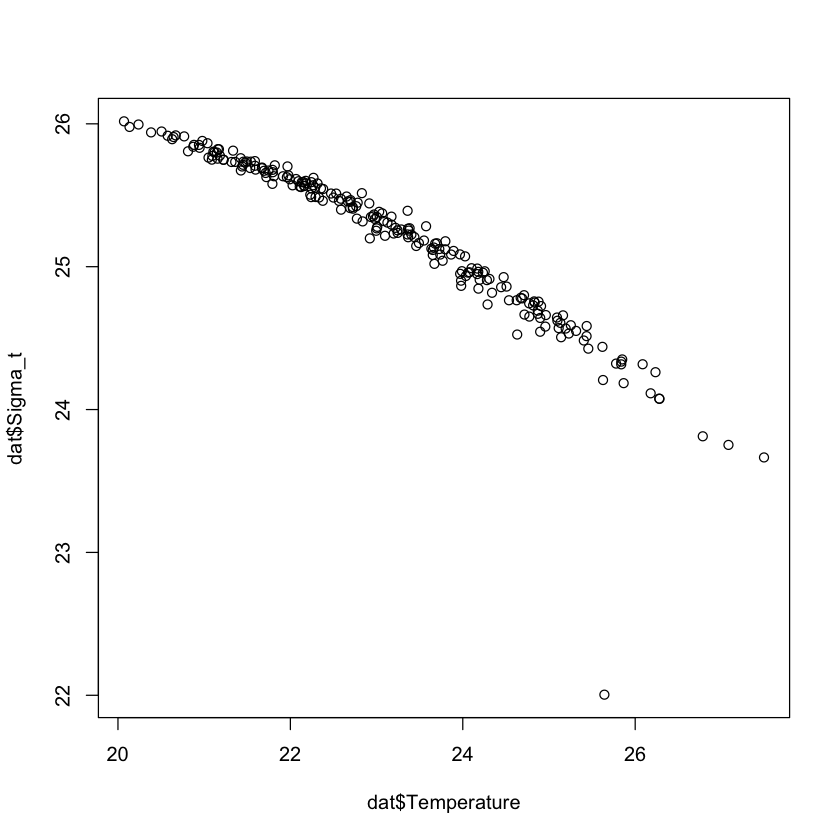

In [29]:
plot(dat$Temperature, dat$Sigma_t)